In [1]:
import sys
import cmasher as cmr
import os
# Get the current working directory
current_dir = '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/' #os.getcwd()

# Add the src directory to the Python path
src_path = os.path.join(os.path.dirname(current_dir), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from GridMetrics import GridScorer, circle_mask, get_even_odd_times, GridParameters, create_new_result_dir, load_grid_metrics_from_pickle
import json
import matplotlib
from matplotlib.lines import Line2D
import time

In [2]:
def compute_cell_gs_with_positions(G, cell, x_new, y_new, x_attr="x", y_attr="y"):
    """
    Compute grid score for one cell using TRUE spike times in G,
    but temporarily override positions with x_new / y_new.

    This works for both time shifts and spatial projections.
    """

    # Save original positions from G
    x_orig = getattr(G, x_attr)
    y_orig = getattr(G, y_attr)

    # Scorer attribute names (usually "_x" and "_y")
    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    # Save original positions from Scorer
    scorer_x_orig = getattr(G.Scorer, scorer_x_attr)
    scorer_y_orig = getattr(G.Scorer, scorer_y_attr)

    try:
        # Override positions in BOTH G and its Scorer
        setattr(G, x_attr, x_new)
        setattr(G, y_attr, y_new)

        setattr(G.Scorer, scorer_x_attr, x_new)
        setattr(G.Scorer, scorer_y_attr, y_new)

        # Compute grid score using existing pipeline
        gs = G.compute_cell_grid_score(cell)

    finally:
        # Restore original positions
        setattr(G, x_attr, x_orig)
        setattr(G, y_attr, y_orig)

        setattr(G.Scorer, scorer_x_attr, scorer_x_orig)
        setattr(G.Scorer, scorer_y_attr, scorer_y_orig)

    return gs

In [3]:
def project_positions_along_heading(
    x,
    y,
    D,
    arena_width=1.5,
    arena_height=1.5
):
    """
    Project positions forward or backward by spatial distance D
    along the animal's instantaneous movement direction.

    Returns:
        x_proj: projected x positions
        y_proj: projected y positions
        valid: True for projected samples that remain inside
               the original 1.5 m × 1.5 m environment
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Direction of movement at each time point
    vx = np.diff(x, append=x[-1])
    vy = np.diff(y, append=y[-1])

    theta = np.arctan2(vy, vx)

    # Shift by distance D along heading
    dx = D * np.cos(theta)
    dy = D * np.sin(theta)

    x_proj = x + dx
    y_proj = y + dy

    # Center the fixed 2.2 m × 2.2 m arena on the original environment
    x_center = 0 #(np.nanmin(x) + np.nanmax(x)) / 2
    y_center = 0 #(np.nanmin(y) + np.nanmax(y)) / 2

    x_min = x_center - arena_width / 2
    x_max = x_center + arena_width / 2
    y_min = y_center - arena_height / 2
    y_max = y_center + arena_height / 2

    # Mark projected points that remain inside the arena
    valid = (
        np.isfinite(x_proj) &
        np.isfinite(y_proj) &
        (x_proj >= x_min) &
        (x_proj <= x_max) &
        (y_proj >= y_min) &
        (y_proj <= y_max)
    )

    return x_proj, y_proj, valid

In [4]:
def compute_cell_gs_with_projected_positions(
    G,
    cell,
    D,
    x_attr="x",
    y_attr="y"
):
    """
    Compute grid score after projecting positions by distance D.

    Any projected time point outside the original 2.2 m × 2.2 m
    arena is removed from the position arrays and from every cell's
    aligned spike train.
    """

    # ------------------------------------------------------
    # 1. Original positions
    # ------------------------------------------------------
    x = np.asarray(getattr(G, x_attr), dtype=float)
    y = np.asarray(getattr(G, y_attr), dtype=float)

    # ------------------------------------------------------
    # 2. Project positions and find in-arena samples
    # ------------------------------------------------------
    x_proj, y_proj, valid = project_positions_along_heading(
        x,
        y,
        D,
        arena_width=1.5,
        arena_height=1.5
    )

    valid = np.asarray(valid, dtype=bool)

    if len(valid) != len(x):
        raise ValueError(
            f"Mask length {len(valid)} does not match "
            f"position length {len(x)}."
        )

    if not np.any(valid):
        print(f"Cell {cell}, D={D:.2f}: no valid samples")
        return np.nan

    x_valid = np.asarray(x_proj)[valid]
    y_valid = np.asarray(y_proj)[valid]

    # ------------------------------------------------------
    # 3. Save original data
    # ------------------------------------------------------
    G_x_original = getattr(G, x_attr)
    G_y_original = getattr(G, y_attr)

    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    scorer_x_original = getattr(G.Scorer, scorer_x_attr)
    scorer_y_original = getattr(G.Scorer, scorer_y_attr)

    scorer_spikes_original = G.Scorer._spikes

    # ------------------------------------------------------
    # 4. Crop every cell's binary spike train
    # ------------------------------------------------------
    if not isinstance(scorer_spikes_original, dict):
        raise TypeError(
            "Expected G.Scorer._spikes to be a dictionary."
        )

    scorer_spikes_valid = {}

    for cell_id, spike_train in scorer_spikes_original.items():
        spike_train = np.asarray(spike_train)

        if len(spike_train) != len(valid):
            raise ValueError(
                f"Cell {cell_id} spike length {len(spike_train)} "
                f"does not match position length {len(valid)}."
            )

        scorer_spikes_valid[cell_id] = spike_train[valid]

    # G may also contain its own spike dictionary
    has_G_spikes = hasattr(G, "spikes")
    G_spikes_original = None
    G_spikes_valid = None

    if has_G_spikes and isinstance(G.spikes, dict):
        G_spikes_original = G.spikes
        G_spikes_valid = {}

        for cell_id, spike_train in G_spikes_original.items():
            spike_train = np.asarray(spike_train)

            if len(spike_train) != len(valid):
                raise ValueError(
                    f"G.spikes cell {cell_id} has length "
                    f"{len(spike_train)}, expected {len(valid)}."
                )

            G_spikes_valid[cell_id] = spike_train[valid]

    # ------------------------------------------------------
    # 5. Temporarily use cropped data
    # ------------------------------------------------------
    try:
        setattr(G, x_attr, x_valid)
        setattr(G, y_attr, y_valid)

        setattr(G.Scorer, scorer_x_attr, x_valid)
        setattr(G.Scorer, scorer_y_attr, y_valid)

        G.Scorer._spikes = scorer_spikes_valid

        if G_spikes_valid is not None:
            G.spikes = G_spikes_valid

        # Positions are already installed, so calculate directly
        gs = G.compute_cell_grid_score(cell)

    finally:
        # --------------------------------------------------
        # 6. Restore original data
        # --------------------------------------------------
        setattr(G, x_attr, G_x_original)
        setattr(G, y_attr, G_y_original)

        setattr(G.Scorer, scorer_x_attr, scorer_x_original)
        setattr(G.Scorer, scorer_y_attr, scorer_y_original)

        G.Scorer._spikes = scorer_spikes_original

        if G_spikes_original is not None:
            G.spikes = G_spikes_original

    return gs

In [5]:
rat = 'r1'
mod = '3'
exp = 'OF'

general_results_working_directory = os.path.join(current_dir, 'results')
session_results_directory = create_new_result_dir(general_results_working_directory, rat+mod + '/Spatial shift')
G = GridParameters(rat, mod, exp, precompute=True)
print("keys:", G.__dict__.keys())

G.get_all_orientations_and_spacings()

G.save_class(session_results_directory)

Directory /Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/results/r13/Spatial shift already exists


/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/src/GridMetrics.py:387: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))


keys: dict_keys(['rat', 'mod', 'exp', 'delta', 'x', 'y', 'spikes', 'n_neurons', 'Scorer', 'grid_scores', 'mask_radius', 'orientation', 'spacing'])
Computing orientation of all cells
 Cell 2/149

/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/src/GridMetrics.py:387: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))


 Cell 148/149Valid cells are 27 out of 149


In [6]:
d_values = np.arange(-0.50, 0.52, 0.02)

# Create ONE GridParameters object
G = GridParameters(rat, mod, exp, precompute=False)

n_cells = len(G.spikes)
grid_scores = np.zeros((len(d_values), n_cells))

for i, D in enumerate(d_values):
    print(f"Computing D = {D}")

    # Just change delta instead of rebuilding object
    for cell in range(n_cells):
        grid_scores[i, cell] = compute_cell_gs_with_projected_positions(G, cell, D)

results_save_path = session_results_directory
np.save(results_save_path + '/grid_scores.npy', grid_scores)

Computing D = -0.5
Computing D = -0.48
Computing D = -0.45999999999999996
Computing D = -0.43999999999999995
Computing D = -0.41999999999999993
Computing D = -0.3999999999999999
Computing D = -0.3799999999999999
Computing D = -0.3599999999999999
Computing D = -0.33999999999999986
Computing D = -0.31999999999999984
Computing D = -0.2999999999999998
Computing D = -0.2799999999999998
Computing D = -0.2599999999999998
Computing D = -0.23999999999999977
Computing D = -0.21999999999999975
Computing D = -0.19999999999999973
Computing D = -0.17999999999999972
Computing D = -0.1599999999999997
Computing D = -0.13999999999999968
Computing D = -0.11999999999999966
Computing D = -0.09999999999999964
Computing D = -0.07999999999999963
Computing D = -0.05999999999999961
Computing D = -0.03999999999999959
Computing D = -0.019999999999999574
Computing D = 4.440892098500626e-16
Computing D = 0.020000000000000462
Computing D = 0.04000000000000048
Computing D = 0.0600000000000005
Computing D = 0.08000000

In [7]:
# best d per cell (argmax across delta axis)
best_d_idx = np.argmax(grid_scores, axis=0)
gs_max = np.max(grid_scores, axis=0)
best_d_values = d_values[best_d_idx]

print("best_d_values defined, shape:", best_d_values.shape)

best_d_values defined, shape: (149,)


In [8]:
# loading shuffled grid scores
temporal_shift_path = create_new_result_dir(general_results_working_directory, rat+mod + '/Temporal shift')
temporal_results = np.load(temporal_shift_path + '/results.npy', allow_pickle=True).item()

Directory /Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/results/r13/Temporal shift already exists


In [9]:
# classifying predictive grid cells
exceed_thresh = 5
grid_cell_thresh = 0.5
max_grid_score_min = 0.3
idx0 = int(np.where(np.abs(d_values) < 1e-6)[0][0])

non_grid_cells = temporal_results['gs0_true'] < grid_cell_thresh # cells that are not "classic" grid cells
predictive_cells = best_d_values > d_values[idx0] # cells that have their best shift negative (i.e., best grid score is at a prospective shift)
above_chance_cells = temporal_results['counts_gt_gsmax'] < exceed_thresh # cells that have their max grid score greater than the shuffle distribution
griddy_shifted_cells = gs_max > max_grid_score_min # the maximum grid score at the shifted value is greater than a minimum value
predictive_grid_cells = (non_grid_cells & predictive_cells & above_chance_cells & griddy_shifted_cells)

print('# predictive grid cells / # non-grid cells:' + str(np.sum(predictive_grid_cells)) + '/' + str(np.sum(non_grid_cells)))
print('Predictive grid cell ids:' + str(np.argwhere(predictive_grid_cells == 1)[:, 0]))
print('Grid score at delta = 0:' + str(temporal_results['gs0_true'][predictive_grid_cells]))
print('Grid score at delta max:' + str(gs_max[predictive_grid_cells]))

# predictive grid cells / # non-grid cells:13/111
Predictive grid cell ids:[ 19  35  36  42  55  73 103 107 110 115 121 129 139]
Grid score at delta = 0:[ 0.48538427  0.37598144  0.33227072  0.29626585  0.29159538  0.431108
  0.49203619  0.01177164 -0.14141449  0.43329189  0.42243043  0.15969141
  0.03677081]
Grid score at delta max:[0.6096012  0.48347849 0.37916652 0.48595717 0.41354937 0.48455109
 0.5558099  0.31089721 0.32938928 0.90297586 0.47878357 0.47145683
 0.32904798]


In [10]:
np.save(results_save_path + '/predictive_grid_cells.npy', predictive_grid_cells)
np.save(results_save_path + '/best_d.npy', best_d_values)
np.save(results_save_path + '/grid_scores.npy', grid_scores)

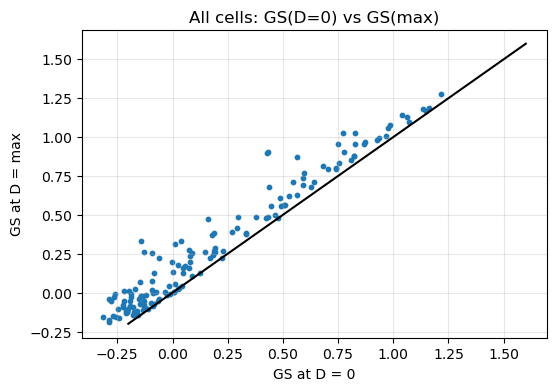

In [11]:
# GS at D=0
gs0 = grid_scores[idx0, :]

# GS(max) for each cell across Ds
gsmax = np.max(grid_scores, axis=0)

plt.figure(figsize=(6, 4))
plt.plot([-0.2, 1.6], [-0.2, 1.6], 'k-')
plt.scatter(gs0, gsmax, s=10)
plt.xlabel("GS at D = 0")
plt.ylabel("GS at D = max")
plt.title("All cells: GS(D=0) vs GS(max)")
plt.grid(alpha=0.3)
plt.savefig(results_save_path + '/GS_D_0_vs_GS_D_max.png')
plt.savefig(results_save_path + '/GS_D_0_vs_GS_D_max.svg', format = 'svg')
plt.show()

In [12]:
def plot_d_curve(cell, delta_values, grid_scores):
    """
    Plot grid score as a function of D for a given cell.
    """
    gs = grid_scores[:, cell]         # grid scores for this cell across Ds

    plt.figure(figsize=(10, 4))
    plt.plot(delta_values, gs, marker='o')
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)

    plt.title(f'Cell {cell}: Grid Score vs D')
    plt.xlabel('D (cm)')
    plt.ylabel('Grid Score')
    plt.grid(alpha=0.3)

    # Print maximum + which delta produced it
    best_idx = np.argmax(gs)
    print(f'Best grid score:' + str(gs[best_idx]) +  'at delta = ' + str(delta_values[best_idx]))

Best grid score:[0.6096012]at delta = 0.10000000000000053


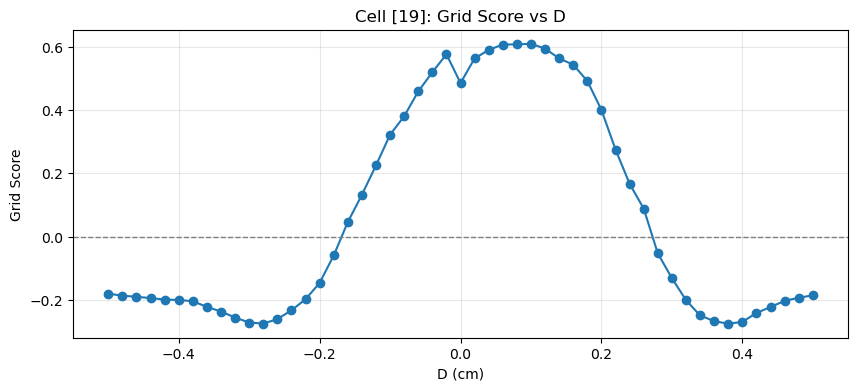

Best grid score:[0.48347849]at delta = 0.0600000000000005


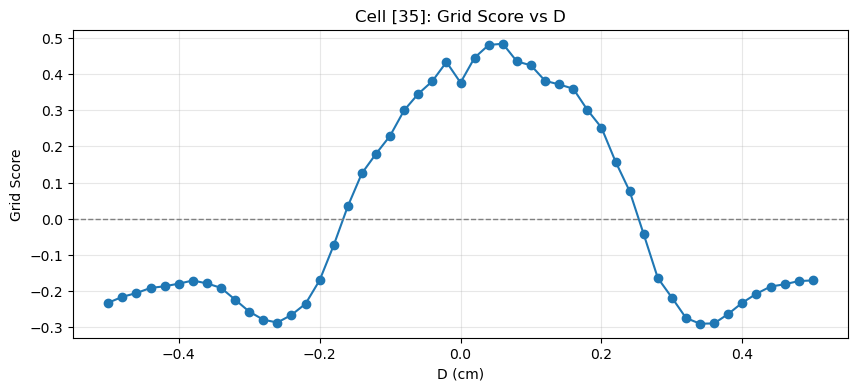

Best grid score:[0.37916652]at delta = 0.08000000000000052


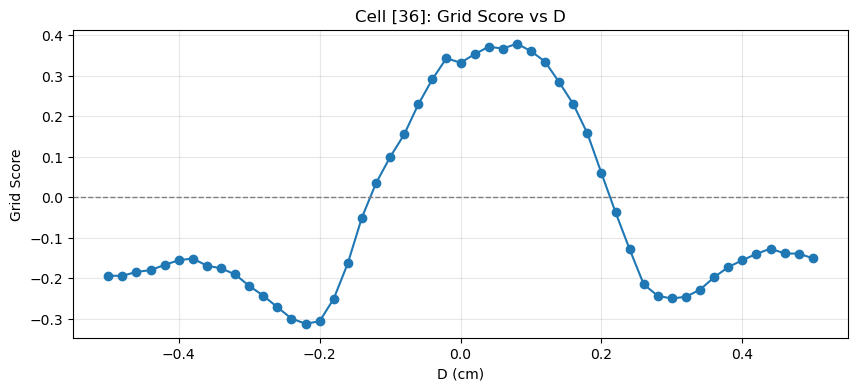

Best grid score:[0.48595717]at delta = 0.10000000000000053


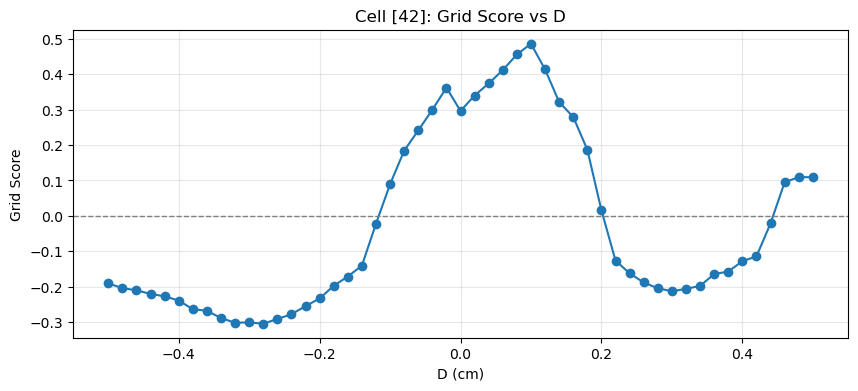

Best grid score:[0.41354937]at delta = 0.04000000000000048


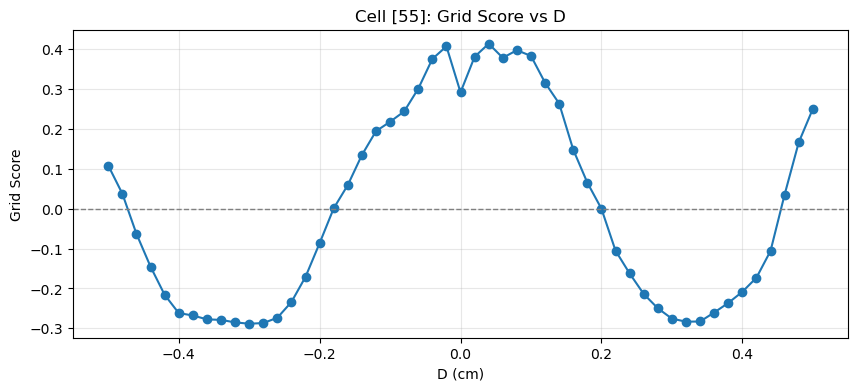

Best grid score:[0.48455109]at delta = 0.0600000000000005


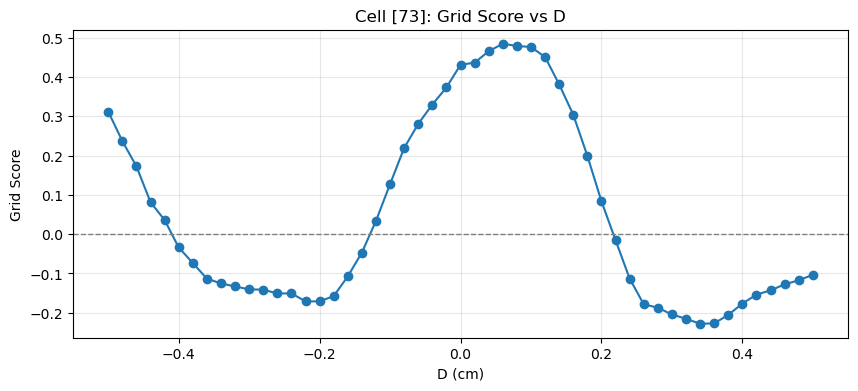

Best grid score:[0.5558099]at delta = 0.0600000000000005


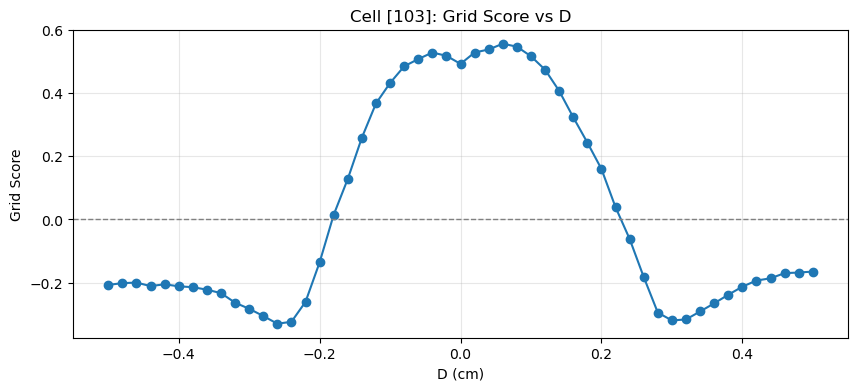

Best grid score:[0.31089721]at delta = 0.14000000000000057


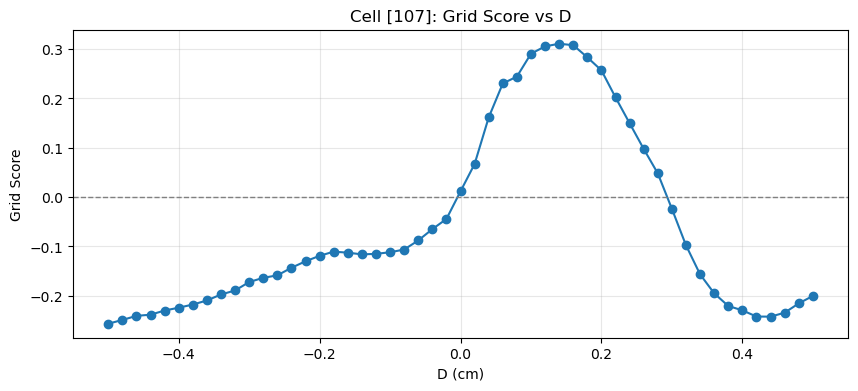

Best grid score:[0.32938928]at delta = 0.20000000000000062


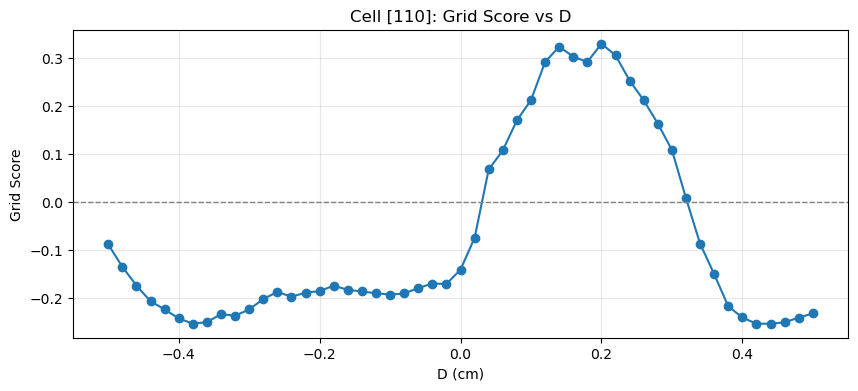

Best grid score:[0.90297586]at delta = 0.5000000000000009


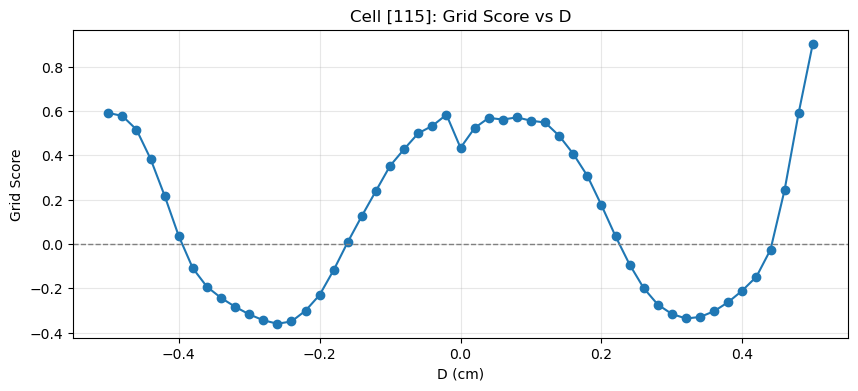

Best grid score:[0.47878357]at delta = 0.020000000000000462


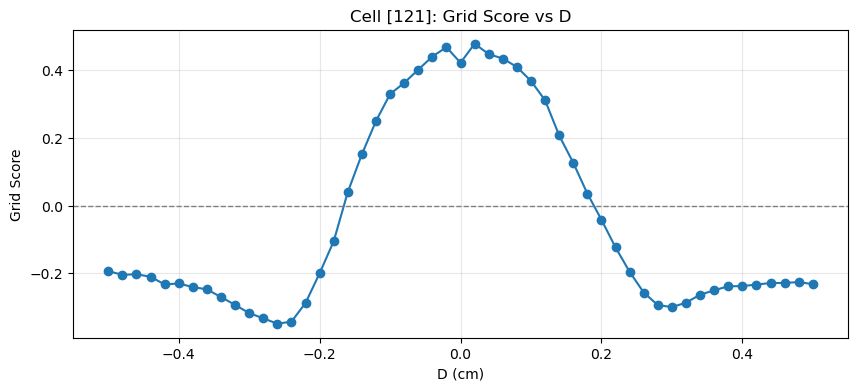

Best grid score:[0.47145683]at delta = 0.04000000000000048


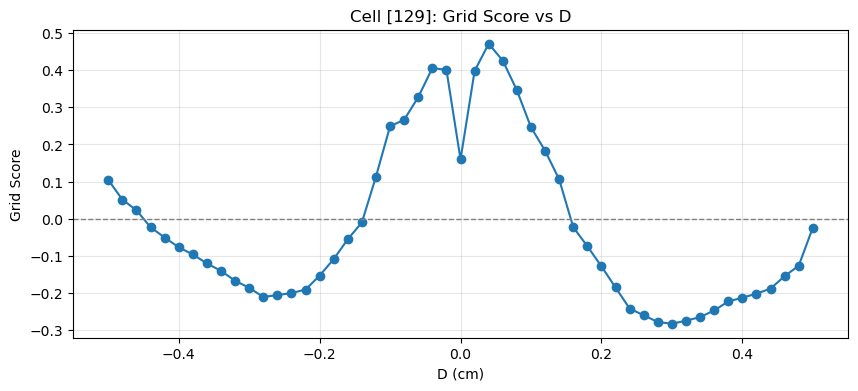

Best grid score:[0.32904798]at delta = 0.020000000000000462


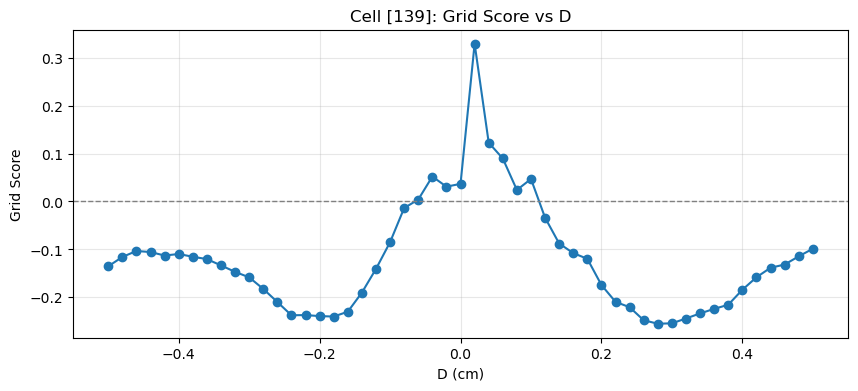

In [13]:
predictive_grid_cell_ids = np.argwhere(predictive_grid_cells == 1)
for ii in range(len(predictive_grid_cell_ids)):
    plot_d_curve(predictive_grid_cell_ids[ii], d_values, grid_scores)
    plt.savefig(results_save_path + '/Cell_' + str(predictive_grid_cell_ids[ii]) + '_d_tuning_curve.png')
    plt.savefig(results_save_path + '/Cell_' + str(predictive_grid_cell_ids[ii]) + '_d_tuning_curve.svg', format = 'svg')
    plt.show()

In [14]:
def compute_cell_ratemap_with_projected_positions(
    G,
    cell,
    D,
    x_attr="x",
    y_attr="y",
    arena_width=1.5,
    arena_height=1.5
):
    """
    Compute a ratemap after shifting positions by spatial distance D.

    Any projected time point that falls outside the original
    1.5 m × 1.5 m arena is removed from the position arrays and
    from every aligned spike train before the ratemap is calculated.
    """

    # 1. Original position arrays
    x = np.asarray(getattr(G, x_attr), dtype=float)
    y = np.asarray(getattr(G, y_attr), dtype=float)

    # 2. Project positions and obtain the in-arena mask
    x_proj, y_proj, valid = project_positions_along_heading(
        x,
        y,
        D,
        arena_width=arena_width,
        arena_height=arena_height
    )

    x_proj = np.asarray(x_proj, dtype=float)
    y_proj = np.asarray(y_proj, dtype=float)
    valid = np.asarray(valid, dtype=bool)

    # Basic checks
    if valid.shape != x.shape:
        raise ValueError(
            f"Valid-mask shape {valid.shape} does not match "
            f"position shape {x.shape}."
        )

    if not np.any(valid):
        raise ValueError(
            f"Cell {cell}, D={D:.2f}: "
            "no projected samples remain inside the arena."
        )

    # 3. Remove out-of-arena samples completely
    x_valid = x_proj[valid]
    y_valid = y_proj[valid]

    # 4. Save original position data
    G_x_original = getattr(G, x_attr)
    G_y_original = getattr(G, y_attr)

    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    scorer_x_original = getattr(G.Scorer, scorer_x_attr)
    scorer_y_original = getattr(G.Scorer, scorer_y_attr)

    # 5. Save and crop the scorer spike dictionary
    scorer_spikes_original = G.Scorer._spikes

    if not isinstance(scorer_spikes_original, dict):
        raise TypeError(
            "Expected G.Scorer._spikes to be a dictionary."
        )

    scorer_spikes_valid = {}

    for cell_id, spike_train in scorer_spikes_original.items():
        spike_train = np.asarray(spike_train)

        if len(spike_train) != len(valid):
            raise ValueError(
                f"Cell {cell_id}: spike length {len(spike_train)} "
                f"does not match position length {len(valid)}."
            )

        scorer_spikes_valid[cell_id] = spike_train[valid]

    # 6. G may also store an aligned spike dictionary
    has_G_spikes = (
        hasattr(G, "spikes")
        and isinstance(G.spikes, dict)
    )

    if has_G_spikes:
        G_spikes_original = G.spikes
        G_spikes_valid = {}

        for cell_id, spike_train in G_spikes_original.items():
            spike_train = np.asarray(spike_train)

            if len(spike_train) != len(valid):
                raise ValueError(
                    f"G.spikes cell {cell_id}: spike length "
                    f"{len(spike_train)} does not match "
                    f"position length {len(valid)}."
                )

            G_spikes_valid[cell_id] = spike_train[valid]

    try:
        # 7. Temporarily install cropped positions and spikes
        setattr(G, x_attr, x_valid)
        setattr(G, y_attr, y_valid)

        setattr(G.Scorer, scorer_x_attr, x_valid)
        setattr(G.Scorer, scorer_y_attr, y_valid)

        G.Scorer._spikes = scorer_spikes_valid

        if has_G_spikes:
            G.spikes = G_spikes_valid

        # 8. Calculate the ratemap
        ratemap = G.Scorer.calculate_ratemap(
            cell=cell,
            delta=G.delta
        )

    finally:
        # 9. Restore all original data
        setattr(G, x_attr, G_x_original)
        setattr(G, y_attr, G_y_original)

        setattr(G.Scorer, scorer_x_attr, scorer_x_original)
        setattr(G.Scorer, scorer_y_attr, scorer_y_original)

        G.Scorer._spikes = scorer_spikes_original

        if has_G_spikes:
            G.spikes = G_spikes_original

    print(
        f"Cell {cell}, D={D:.2f}: "
        f"kept {valid.sum()} / {len(valid)} samples "
        f"({100 * valid.mean():.1f}%)"
    )

    return ratemap

In [15]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

def rgb_ratemap(im, cmap="jet", smooth=True):
    cm = plt.cm.get_cmap(cmap)

    np.seterr(invalid="ignore")
    im = np.array(im, dtype=float)
    im = np.nan_to_num(im, nan=0.0)

    visited = im > 0
    im2 = im.copy()
    im2[~visited] = np.nan

    mn = np.nanmin(im2)
    mx = np.nanmax(im2)

    if not np.isfinite(mn) or not np.isfinite(mx) or mx == mn:
        im01 = np.zeros_like(im, dtype=float)
    else:
        im01 = (im - mn) / (mx - mn)

    im01 = np.nan_to_num(im01, nan=0.0)
    im01 = np.clip(im01, 0.0, 1.0)

    if smooth and HAS_CV2:
        im01 = cv2.GaussianBlur(im01, (3, 3), sigmaX=1, sigmaY=0)

        if np.any(visited):
            mn2 = np.min(im01[visited])
            mx2 = np.max(im01[visited])
            if np.isfinite(mn2) and np.isfinite(mx2) and mx2 != mn2:
                im01 = (im01 - mn2) / (mx2 - mn2)
                im01 = np.clip(im01, 0.0, 1.0)

    rgb_img = cm(im01)[..., :3]
    rgb_img = (rgb_img * 255).astype(np.uint8)
    return rgb_img

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_30421/2630727687.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cell = int(predictive_grid_cell_ids[ii])


Cell 19, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 19, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 19, D=0.10: kept 696729 / 732099 samples (95.2%)


/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_30421/2062097205.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmap)


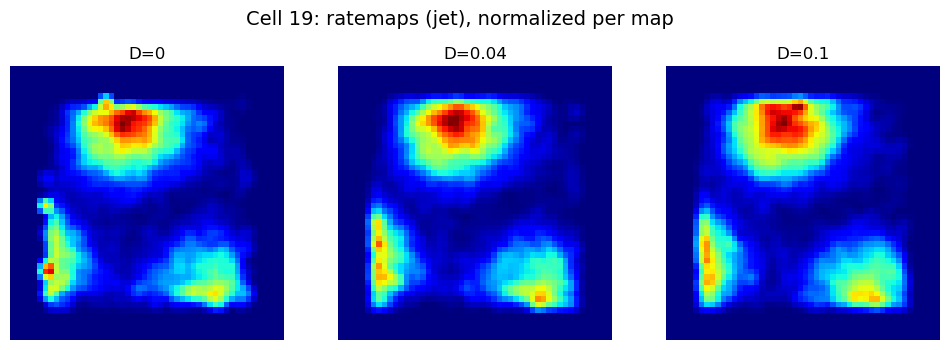

Cell 35, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 35, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 35, D=0.06: kept 718819 / 732099 samples (98.2%)


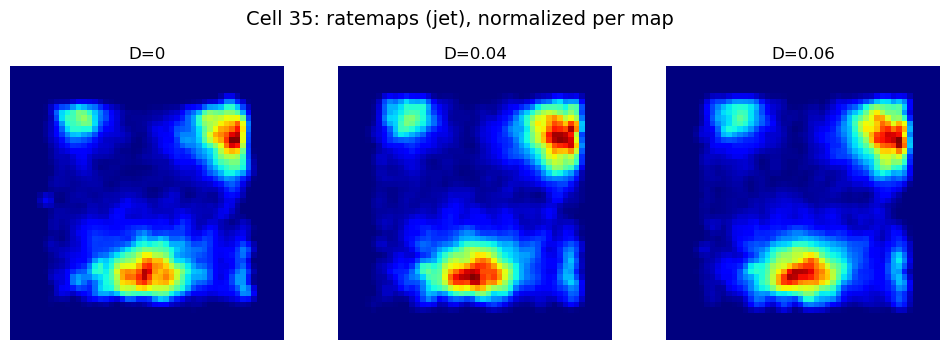

Cell 36, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 36, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 36, D=0.08: kept 707673 / 732099 samples (96.7%)


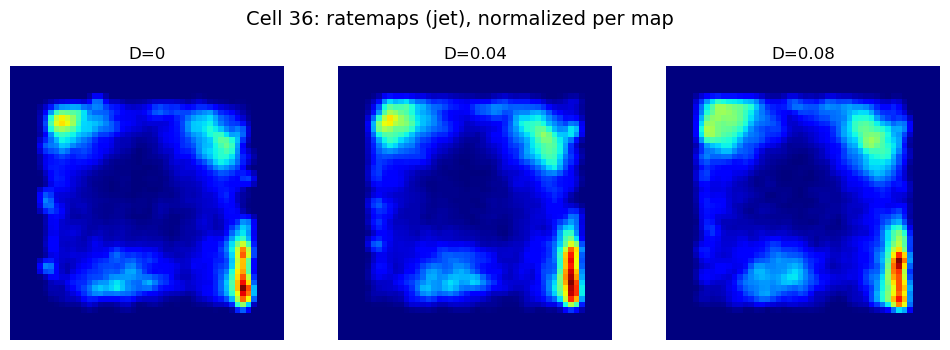

Cell 42, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 42, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 42, D=0.10: kept 696729 / 732099 samples (95.2%)


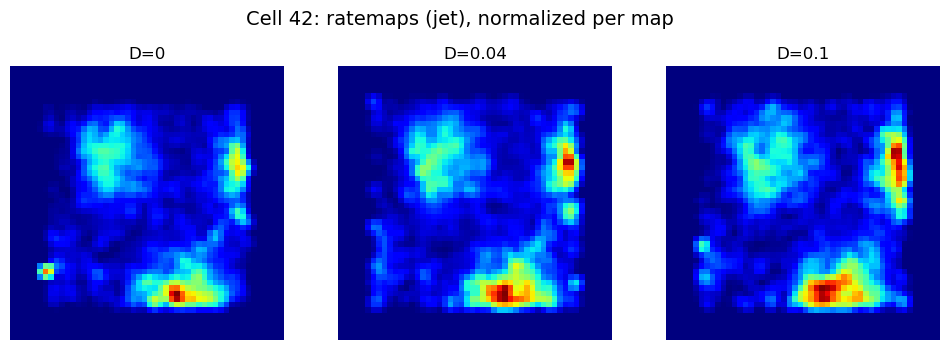

Cell 55, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 55, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 55, D=0.04: kept 728025 / 732099 samples (99.4%)


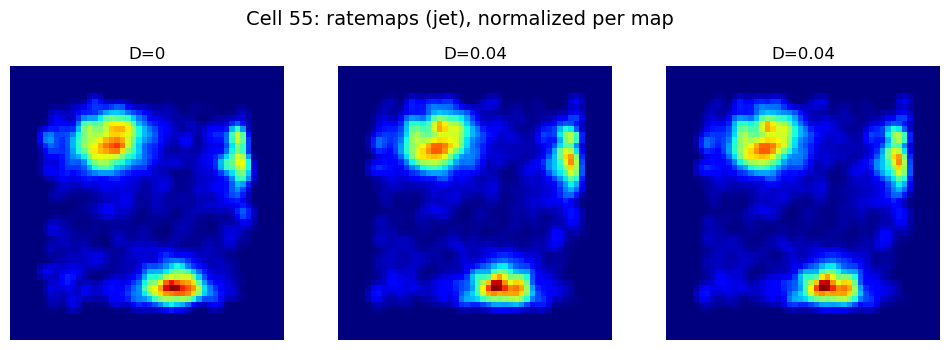

Cell 73, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 73, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 73, D=0.06: kept 718819 / 732099 samples (98.2%)


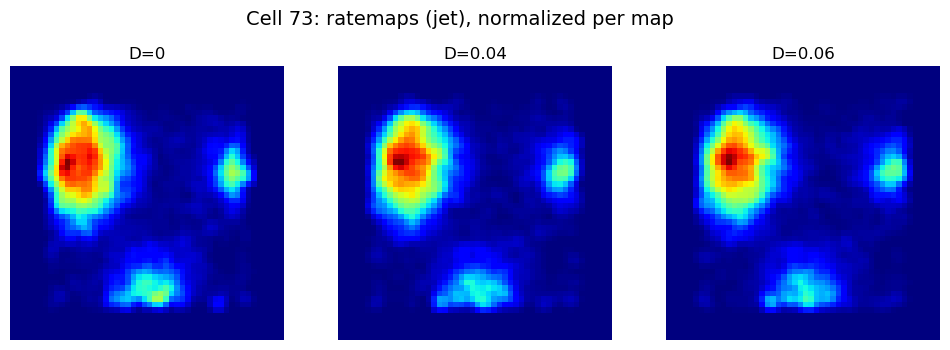

Cell 103, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 103, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 103, D=0.06: kept 718819 / 732099 samples (98.2%)


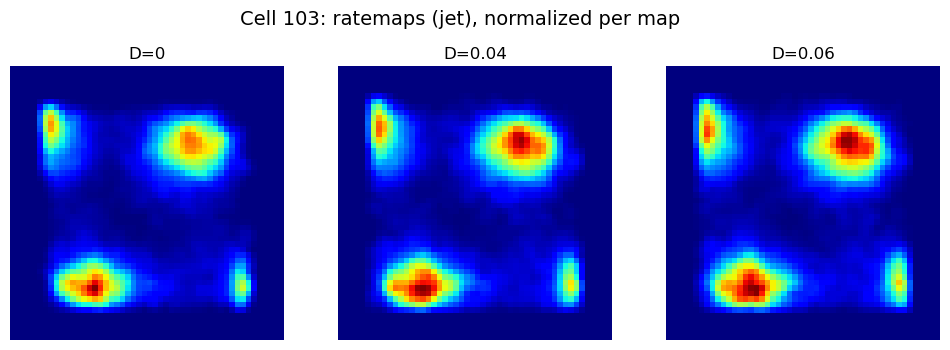

Cell 107, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 107, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 107, D=0.14: kept 676372 / 732099 samples (92.4%)


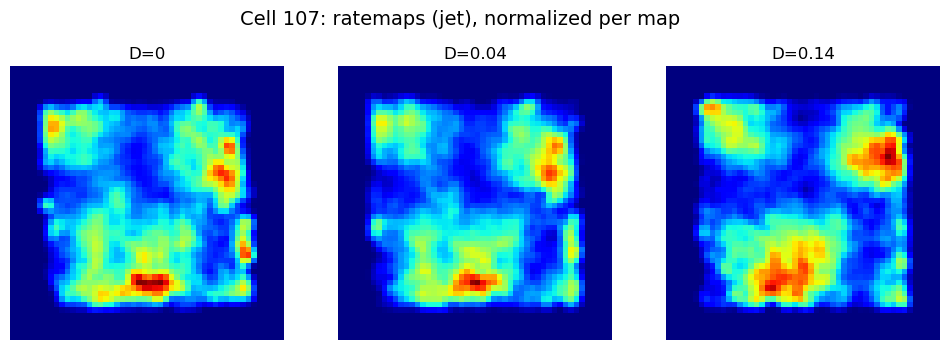

Cell 110, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 110, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 110, D=0.20: kept 643443 / 732099 samples (87.9%)


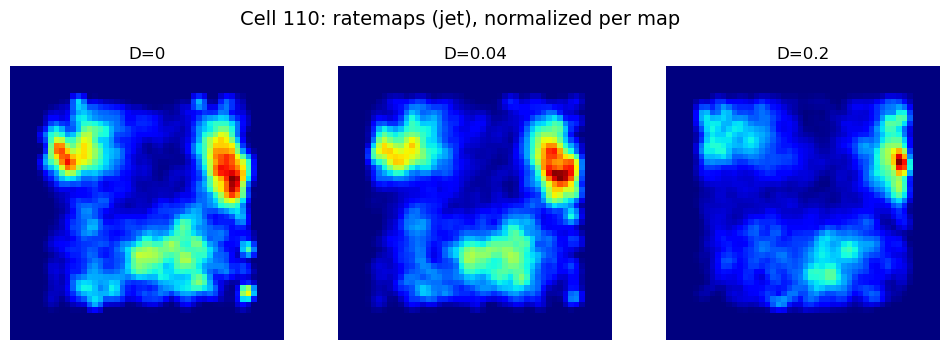

Cell 115, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 115, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 115, D=0.50: kept 475232 / 732099 samples (64.9%)


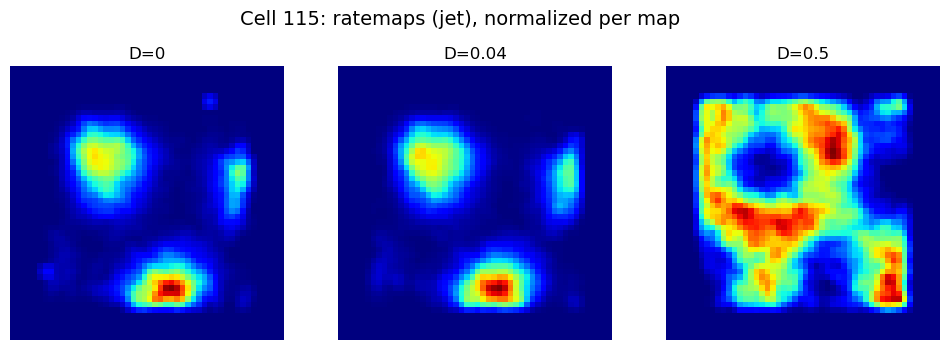

Cell 121, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 121, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 121, D=0.02: kept 731810 / 732099 samples (100.0%)


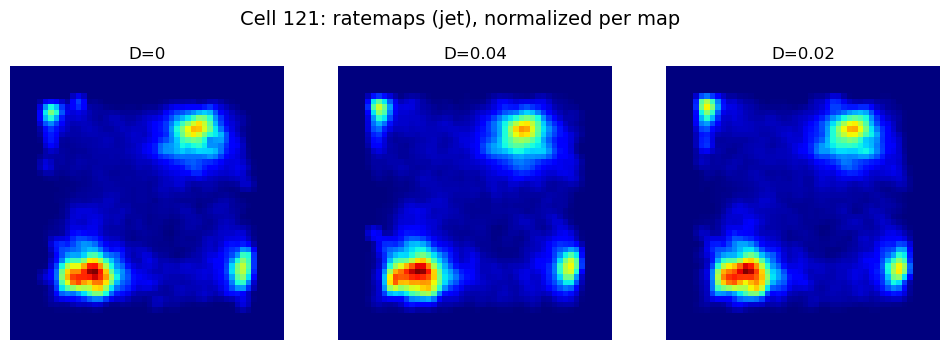

Cell 129, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 129, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 129, D=0.04: kept 728025 / 732099 samples (99.4%)


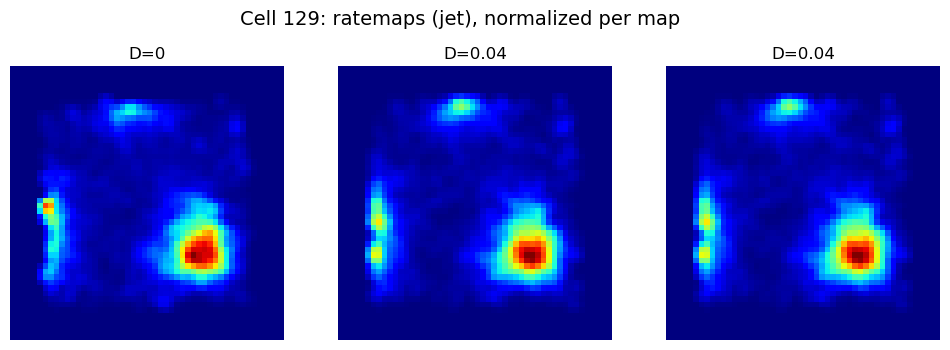

Cell 139, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 139, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 139, D=0.02: kept 731810 / 732099 samples (100.0%)


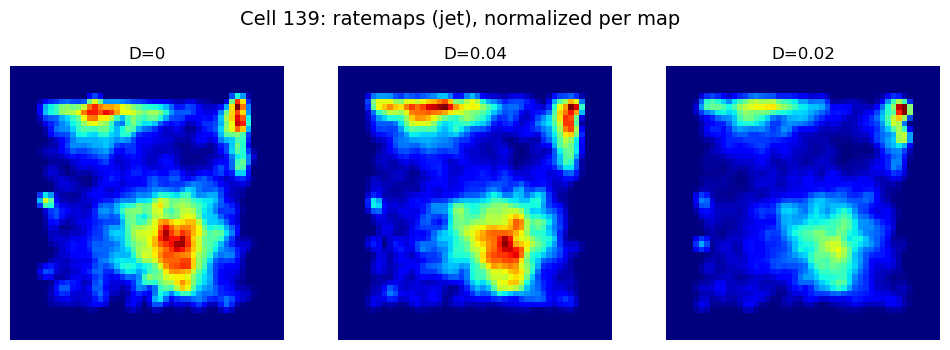

In [16]:
for ii in range(len(predictive_grid_cell_ids)):
    cell = int(predictive_grid_cell_ids[ii])

    r0 = compute_cell_ratemap_with_projected_positions(G, cell, D = 0)
    rmid = compute_cell_ratemap_with_projected_positions(G, cell, D = 0.04)
    rbest = compute_cell_ratemap_with_projected_positions(G, cell, D = best_d_values[cell])

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    titles = ["D=0", "D=0.04", "D=" + str(np.round(best_d_values[cell], 3))]
    maps = [r0, rmid, rbest]

    for a, R, t in zip(ax, maps, titles):
        a.imshow(rgb_ratemap(R))
        a.set_title(t)
        a.axis("off")

    fig.suptitle(f"Cell {cell}: ratemaps (jet), normalized per map", fontsize=14)
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_normalized_rate_map.png')
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_normalized_rate_map.svg', format='svg')
    plt.show()

In [17]:
def compute_cell_SAC_with_projected_positions(
    G,
    cell,
    D,
    x_attr="x",
    y_attr="y",
    arena_width=1.5,
    arena_height=1.5
):
    """
    Compute a ratemap after shifting positions by spatial distance D.

    Any projected time point that falls outside the original
    1.5 m × 1.5 m arena is removed from the position arrays and
    from every aligned spike train before the ratemap is calculated.
    """

    # 1. Original position arrays
    x = np.asarray(getattr(G, x_attr), dtype=float)
    y = np.asarray(getattr(G, y_attr), dtype=float)

    # 2. Project positions and obtain the in-arena mask
    x_proj, y_proj, valid = project_positions_along_heading(
        x,
        y,
        D,
        arena_width=arena_width,
        arena_height=arena_height
    )

    x_proj = np.asarray(x_proj, dtype=float)
    y_proj = np.asarray(y_proj, dtype=float)
    valid = np.asarray(valid, dtype=bool)

    # Basic checks
    if valid.shape != x.shape:
        raise ValueError(
            f"Valid-mask shape {valid.shape} does not match "
            f"position shape {x.shape}."
        )

    if not np.any(valid):
        raise ValueError(
            f"Cell {cell}, D={D:.2f}: "
            "no projected samples remain inside the arena."
        )

    # 3. Remove out-of-arena samples completely
    x_valid = x_proj[valid]
    y_valid = y_proj[valid]

    # 4. Save original position data
    G_x_original = getattr(G, x_attr)
    G_y_original = getattr(G, y_attr)

    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    scorer_x_original = getattr(G.Scorer, scorer_x_attr)
    scorer_y_original = getattr(G.Scorer, scorer_y_attr)

    # 5. Save and crop the scorer spike dictionary
    scorer_spikes_original = G.Scorer._spikes

    if not isinstance(scorer_spikes_original, dict):
        raise TypeError(
            "Expected G.Scorer._spikes to be a dictionary."
        )

    scorer_spikes_valid = {}

    for cell_id, spike_train in scorer_spikes_original.items():
        spike_train = np.asarray(spike_train)

        if len(spike_train) != len(valid):
            raise ValueError(
                f"Cell {cell_id}: spike length {len(spike_train)} "
                f"does not match position length {len(valid)}."
            )

        scorer_spikes_valid[cell_id] = spike_train[valid]

    # 6. G may also store an aligned spike dictionary
    has_G_spikes = (
        hasattr(G, "spikes")
        and isinstance(G.spikes, dict)
    )

    if has_G_spikes:
        G_spikes_original = G.spikes
        G_spikes_valid = {}

        for cell_id, spike_train in G_spikes_original.items():
            spike_train = np.asarray(spike_train)

            if len(spike_train) != len(valid):
                raise ValueError(
                    f"G.spikes cell {cell_id}: spike length "
                    f"{len(spike_train)} does not match "
                    f"position length {len(valid)}."
                )

            G_spikes_valid[cell_id] = spike_train[valid]

    try:
        # 7. Temporarily install cropped positions and spikes
        setattr(G, x_attr, x_valid)
        setattr(G, y_attr, y_valid)

        setattr(G.Scorer, scorer_x_attr, x_valid)
        setattr(G.Scorer, scorer_y_attr, y_valid)

        G.Scorer._spikes = scorer_spikes_valid

        if has_G_spikes:
            G.spikes = G_spikes_valid

        # 8. Calculate the SAC
        SAC = G.Scorer.calculate_sac(
            cell=cell,
            delta=G.delta
        )

    finally:
        # 9. Restore all original data
        setattr(G, x_attr, G_x_original)
        setattr(G, y_attr, G_y_original)

        setattr(G.Scorer, scorer_x_attr, scorer_x_original)
        setattr(G.Scorer, scorer_y_attr, scorer_y_original)

        G.Scorer._spikes = scorer_spikes_original

        if has_G_spikes:
            G.spikes = G_spikes_original

    print(
        f"Cell {cell}, D={D:.2f}: "
        f"kept {valid.sum()} / {len(valid)} samples "
        f"({100 * valid.mean():.1f}%)"
    )

    return SAC

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_30421/2327412014.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cell = int(predictive_grid_cell_ids[ii])


Cell 19, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 19, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 19, D=0.10: kept 696729 / 732099 samples (95.2%)


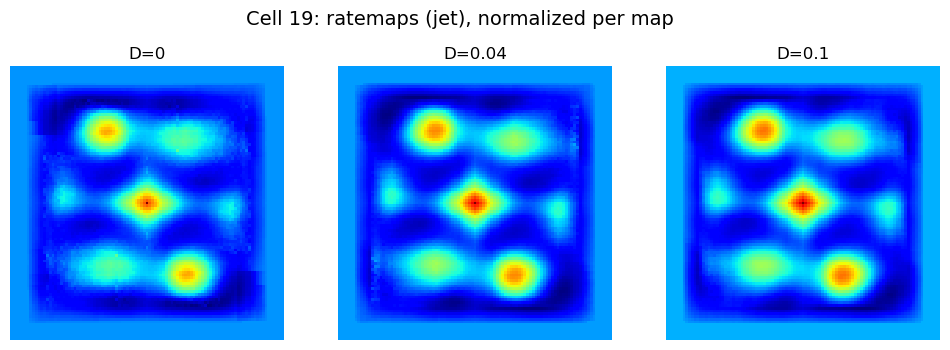

Cell 35, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 35, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 35, D=0.06: kept 718819 / 732099 samples (98.2%)


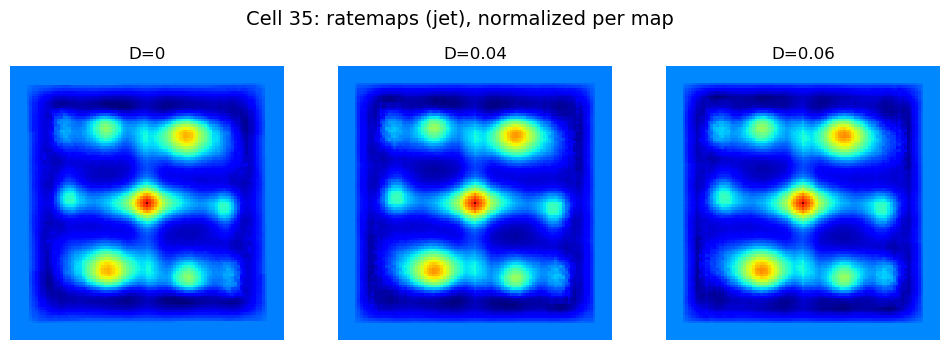

Cell 36, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 36, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 36, D=0.08: kept 707673 / 732099 samples (96.7%)


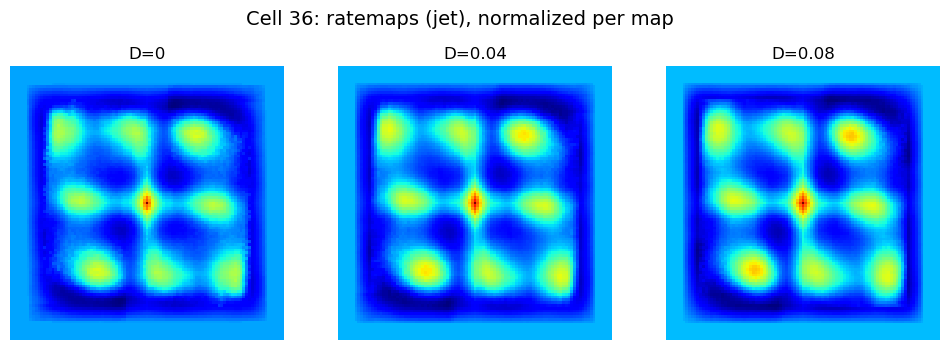

Cell 42, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 42, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 42, D=0.10: kept 696729 / 732099 samples (95.2%)


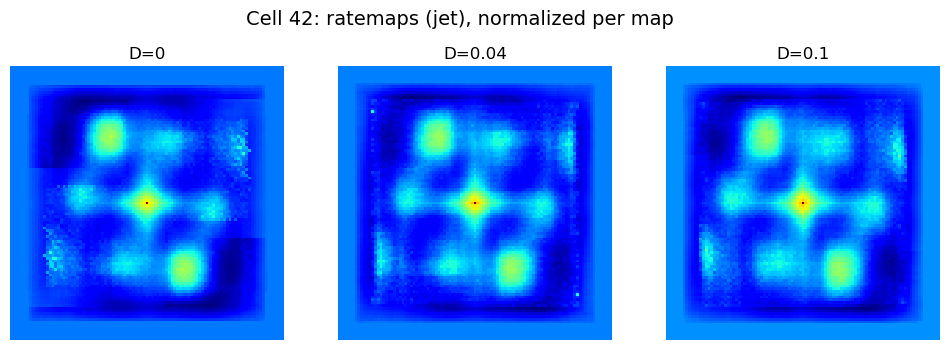

Cell 55, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 55, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 55, D=0.04: kept 728025 / 732099 samples (99.4%)


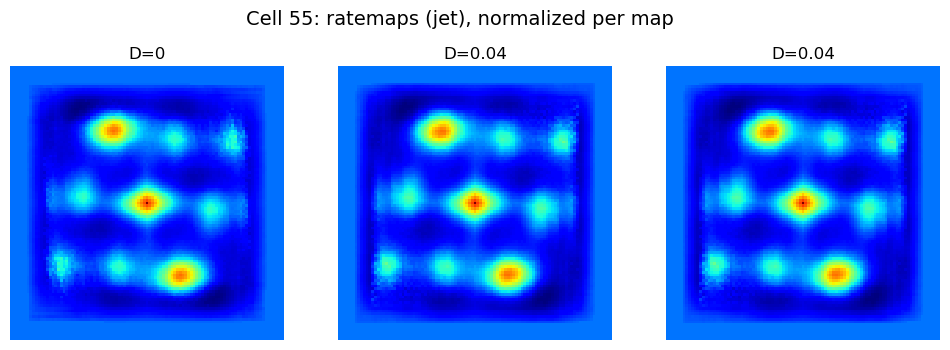

Cell 73, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 73, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 73, D=0.06: kept 718819 / 732099 samples (98.2%)


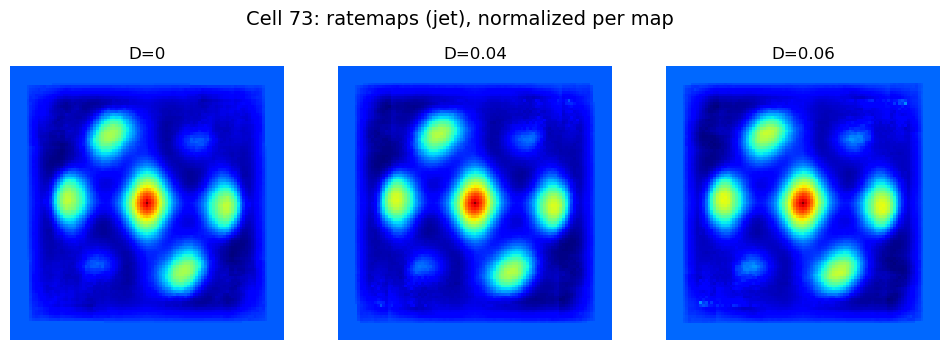

Cell 103, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 103, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 103, D=0.06: kept 718819 / 732099 samples (98.2%)


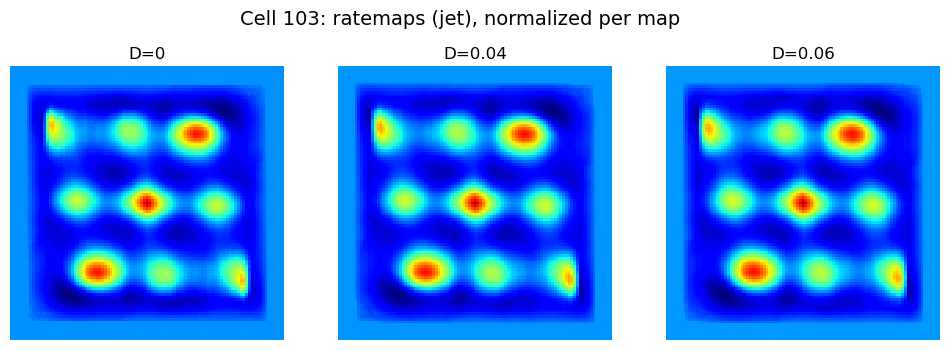

Cell 107, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 107, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 107, D=0.14: kept 676372 / 732099 samples (92.4%)


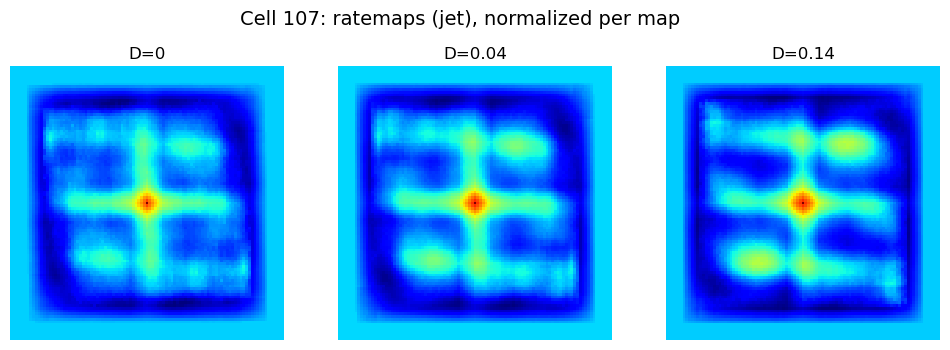

Cell 110, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 110, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 110, D=0.20: kept 643443 / 732099 samples (87.9%)


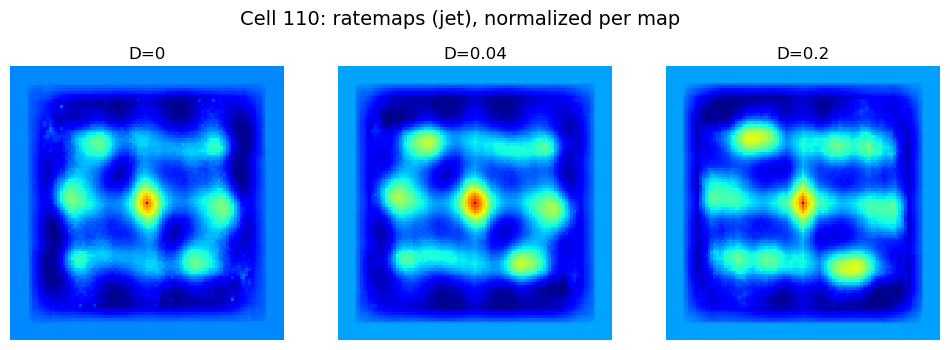

Cell 115, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 115, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 115, D=0.50: kept 475232 / 732099 samples (64.9%)


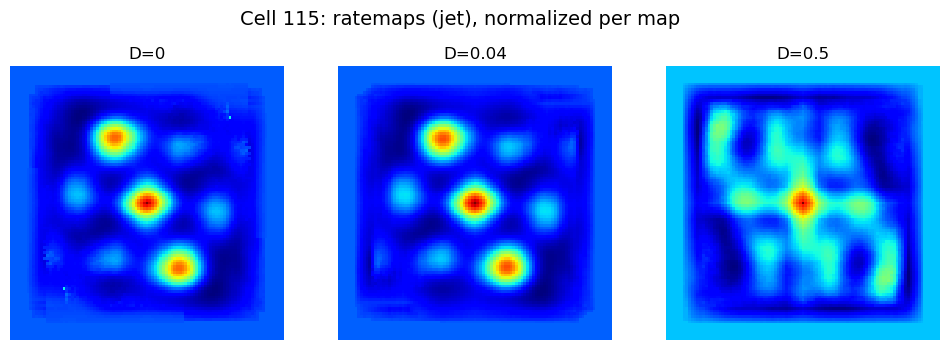

Cell 121, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 121, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 121, D=0.02: kept 731810 / 732099 samples (100.0%)


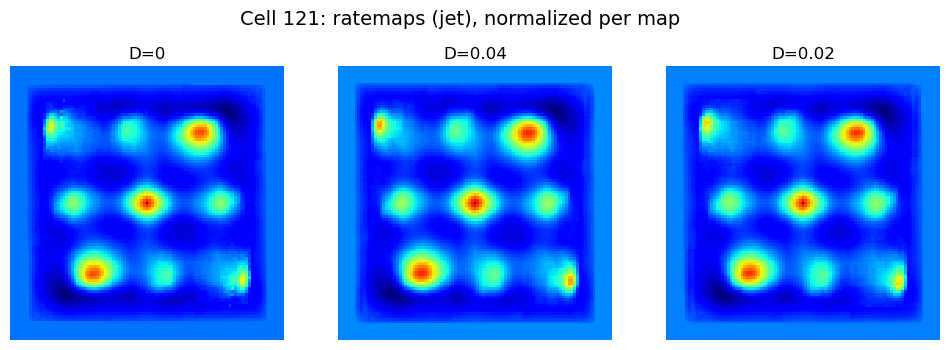

Cell 129, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 129, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 129, D=0.04: kept 728025 / 732099 samples (99.4%)


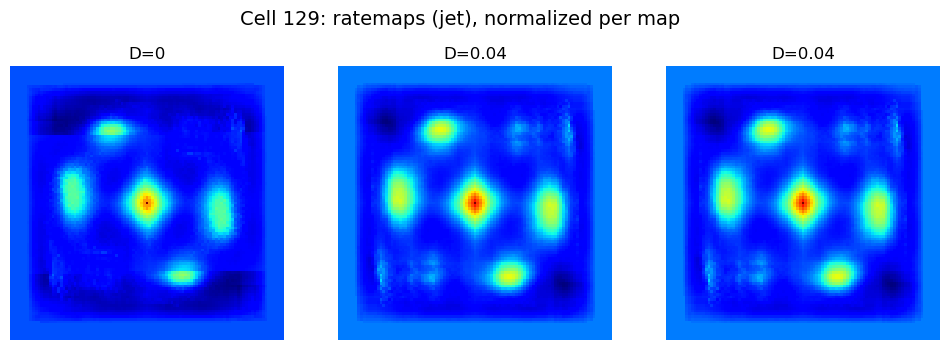

Cell 139, D=0.00: kept 732099 / 732099 samples (100.0%)
Cell 139, D=0.04: kept 728025 / 732099 samples (99.4%)
Cell 139, D=0.02: kept 731810 / 732099 samples (100.0%)


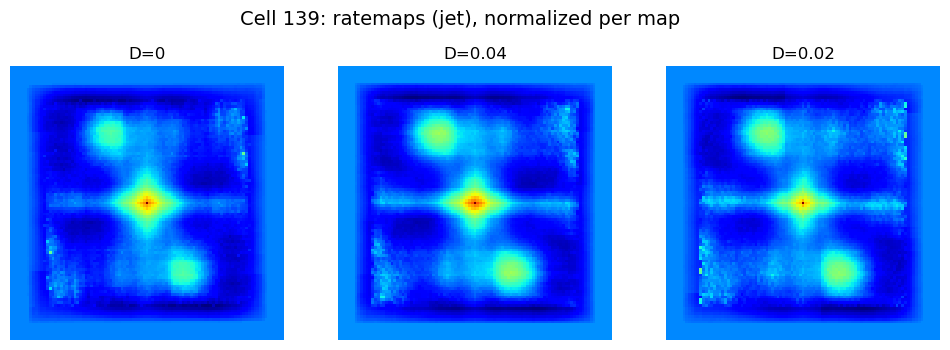

In [18]:
for ii in range(len(predictive_grid_cell_ids)):
    cell = int(predictive_grid_cell_ids[ii])

    sac0 = compute_cell_SAC_with_projected_positions(G, cell, D = 0)
    sacmid = compute_cell_SAC_with_projected_positions(G, cell, D = 0.04)
    sacbest = compute_cell_SAC_with_projected_positions(G, cell, D = best_d_values[cell])

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    titles = ["D=0", "D=0.04", "D=" + str(np.round(best_d_values[cell], 3))]
    maps = [sac0, sacmid, sacbest]

    for a, R, t in zip(ax, maps, titles):
        a.imshow(R, interpolation='nearest', cmap = 'jet')
        a.set_title(t)
        a.axis("off")

    fig.suptitle(f"Cell {cell}: ratemaps (jet), normalized per map", fontsize=14)
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_SAC.png')
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_SAC.svg', format='svg')
    plt.show()


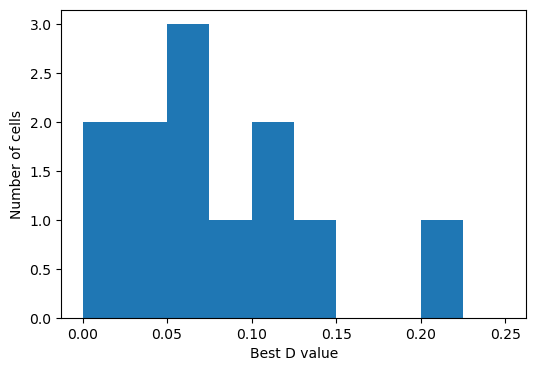

In [19]:
plt.figure(figsize = (6, 4))
plt.hist(best_d_values[predictive_grid_cell_ids], bins = np.linspace(0, 0.25, 11))
plt.xlabel('Best D value')
plt.ylabel('Number of cells')
plt.savefig(results_save_path + '/Best_d_values.png')
plt.savefig(results_save_path + '/Best_d_values.svg', format = 'svg')
plt.show()

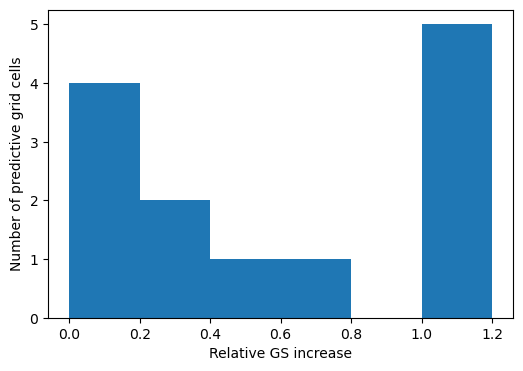

In [20]:
gs_rel_inc_predictive = (gsmax[predictive_grid_cell_ids] - gs0[predictive_grid_cell_ids]) / np.abs(gs0[predictive_grid_cell_ids])
gs_rel_inc_predictive[gs_rel_inc_predictive > 1.0] = 1.1

plt.figure(figsize = (6, 4))
plt.hist(gs_rel_inc_predictive, bins = np.linspace(0, 1.2, 7))
plt.xlabel('Relative GS increase')
plt.ylabel('Number of predictive grid cells')
plt.savefig(results_save_path + '/Relative_GS_increase.png')
plt.savefig(results_save_path + '/Relative_GS_increase.svg', format = 'svg')
plt.show()